In [1]:
# titulo = "Qué nos dicen los resultados de exámenes de los estudiantes"
# tema = "Qué factores afectan a la hora de sacar una mejor nota"

# hipotesis_principal = "Los estudiantes con una buena organización de estudio tienen más probabilidades de sacar mejor nota" 
# Se tienen en cuenta columnas como Attendance, Hours_Studied, Sleep_Hours y Access_to_Resources	

# subhipotesis_1 = "La importancia de la motivación de un estudiante a la hora de la nota final"
# Se tiene en cuenta la columna "Motivation_Level"

# subhipotesis_2 = "El entorno en el que ha crecido el estudiante no afecta tanto en el rendimiento de los exámenes"
# Se tienen en cuenta columnas como Family_Income, Teacher_Quality, School_Type y Parental_Education_Level

#fuente= "Kaggle" https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis/data

In [ ]:
#ANÁLISIS EXPLORATORIO DE DATOS:

In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

print("Path to dataset files:", path)

c:\Users\data_\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\data_\.cache\kagglehub\datasets\grandmaster07\student-exam-performance-dataset-analysis\versions\1


In [4]:
import numpy as np
import pandas as pd

In [5]:
students = pd.read_csv(r"C:\Users\data_\.cache\kagglehub\datasets\grandmaster07\student-exam-performance-dataset-analysis\versions\1\StudentPerformanceFactors.csv")
students

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [6]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [7]:
students.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

In [8]:
students.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [9]:
#Para obtener datos limpios, vamos a analizar las columnas una por una primero:

In [10]:
#para ver los valores únicos de esta columna en un array. Lo vamos a hacer para todas las columnas y así sacar conclusiones
students['Hours_Studied'].unique()

array([23, 19, 24, 29, 25, 17, 21,  9, 10, 14, 22, 15, 12, 20, 11, 13, 16,
       18, 31,  8, 26, 28,  4, 35, 27, 33, 36, 43, 34,  1, 30,  7, 32,  6,
       38,  5,  3,  2, 39, 37, 44])

In [11]:
students['Attendance'].unique() #valores de 0 a 100

array([ 84,  64,  98,  89,  92,  88,  78,  94,  80,  97,  83,  82,  68,
        60,  70,  75,  99,  74,  65,  62,  91,  90,  66,  69,  72,  63,
        61,  86,  77,  71,  67,  87,  73,  96, 100,  81,  95,  79,  85,
        76,  93])

In [12]:
students['Parental_Involvement'].unique()

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [13]:
students['Access_to_Resources'].unique()

<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

In [14]:
students['Extracurricular_Activities'].unique() #puede afectar a la primera columna (Hours_Studied)

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [15]:
students['Sleep_Hours'].unique() #media de horas dormidas cada noche por alumno (0-10). Puede afectar a la primera columna (Hours_Studied)

array([ 7,  8,  6, 10,  9,  5,  4])

In [16]:
students['Previous_Scores'].unique() #podría ser interesante compararlo con la nota final (0-100)

array([ 73,  59,  91,  98,  65,  89,  68,  50,  80,  71,  88,  87,  97,
        72,  74,  70,  82,  58,  99,  84, 100,  75,  54,  90,  94,  51,
        57,  66,  96,  93,  56,  52,  63,  79,  81,  69,  95,  60,  92,
        77,  62,  85,  78,  64,  76,  55,  86,  61,  53,  83,  67])

In [17]:
students['Motivation_Level'].unique()

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [18]:
students['Internet_Access'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [19]:
students['Tutoring_Sessions'].unique()

array([0, 2, 1, 3, 4, 5, 6, 7, 8])

In [20]:
students['Family_Income'].unique()

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [21]:
students['Teacher_Quality'].unique() #sale el valor nan también porque en algunos casos no se tiene el valor de la variable (valor nulo)

<StringArray>
['Medium', 'High', 'Low', nan]
Length: 4, dtype: str

In [22]:
students['School_Type'].unique()

<StringArray>
['Public', 'Private']
Length: 2, dtype: str

In [23]:
students['Peer_Influence'].unique()

<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str

In [24]:
students['Physical_Activity'].unique()

array([3, 4, 2, 1, 5, 0, 6])

In [25]:
students['Learning_Disabilities'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [26]:
students['Parental_Education_Level'].unique() #valores nulos, como ya sabíamos. Puede estra asociado a la clase social del alumno también

<StringArray>
['High School', 'College', 'Postgraduate', nan]
Length: 4, dtype: str

In [27]:
students['Distance_from_Home'].unique() #valores nulos, como ya sabíamos. Puede afectar a las Hours_Studied

<StringArray>
['Near', 'Moderate', 'Far', nan]
Length: 4, dtype: str

In [28]:
students['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [29]:
students['Exam_Score'].unique() #todos han aprobado, por lo que se puede observar, y tenemos un estudiante con un 100/100 (y un 101?)

array([ 67,  61,  74,  71,  70,  66,  69,  72,  68,  65,  64,  60,  63,
        62, 100,  76,  79,  73,  78,  89,  75,  59,  86,  97,  83,  84,
        80,  58,  94,  55,  92,  82,  77, 101,  88,  91,  99,  87,  57,
        96,  98,  95,  85,  93,  56])

In [30]:
#Vamos a ver de qué tipos son los valores nulos que tenemos en el DataFrame

In [31]:
students['Teacher_Quality'].apply(type)

0       <class 'str'>
1       <class 'str'>
2       <class 'str'>
3       <class 'str'>
4       <class 'str'>
            ...      
6602    <class 'str'>
6603    <class 'str'>
6604    <class 'str'>
6605    <class 'str'>
6606    <class 'str'>
Name: Teacher_Quality, Length: 6607, dtype: object

In [32]:
students['Teacher_Quality'].astype('string')

0       Medium
1       Medium
2       Medium
3       Medium
4         High
         ...  
6602    Medium
6603      High
6604    Medium
6605    Medium
6606    Medium
Name: Teacher_Quality, Length: 6607, dtype: string

In [33]:
students['Parental_Education_Level'].apply(type)

0       <class 'str'>
1       <class 'str'>
2       <class 'str'>
3       <class 'str'>
4       <class 'str'>
            ...      
6602    <class 'str'>
6603    <class 'str'>
6604    <class 'str'>
6605    <class 'str'>
6606    <class 'str'>
Name: Parental_Education_Level, Length: 6607, dtype: object

In [34]:
students['Parental_Education_Level'].astype('string')

0        High School
1            College
2       Postgraduate
3        High School
4            College
            ...     
6602     High School
6603     High School
6604    Postgraduate
6605     High School
6606    Postgraduate
Name: Parental_Education_Level, Length: 6607, dtype: string

In [35]:
students['Distance_from_Home'].apply(type)

0       <class 'str'>
1       <class 'str'>
2       <class 'str'>
3       <class 'str'>
4       <class 'str'>
            ...      
6602    <class 'str'>
6603    <class 'str'>
6604    <class 'str'>
6605    <class 'str'>
6606    <class 'str'>
Name: Distance_from_Home, Length: 6607, dtype: object

In [36]:
students['Distance_from_Home'].astype('string')

0           Near
1       Moderate
2           Near
3       Moderate
4           Near
          ...   
6602        Near
6603        Near
6604        Near
6605         Far
6606        Near
Name: Distance_from_Home, Length: 6607, dtype: string

In [37]:
#Comprobamos que las 3 columnas ya son de tipo string:
students['Parental_Education_Level']

0        High School
1            College
2       Postgraduate
3        High School
4            College
            ...     
6602     High School
6603     High School
6604    Postgraduate
6605     High School
6606    Postgraduate
Name: Parental_Education_Level, Length: 6607, dtype: str

In [38]:
students['Parental_Education_Level']

0        High School
1            College
2       Postgraduate
3        High School
4            College
            ...     
6602     High School
6603     High School
6604    Postgraduate
6605     High School
6606    Postgraduate
Name: Parental_Education_Level, Length: 6607, dtype: str

In [39]:
students['Distance_from_Home']

0           Near
1       Moderate
2           Near
3       Moderate
4           Near
          ...   
6602        Near
6603        Near
6604        Near
6605         Far
6606        Near
Name: Distance_from_Home, Length: 6607, dtype: str

In [40]:
#Vemos que son de tipo string en columnas que contienen datos tipo string, por lo que no es necesaria ninguna acción adicional

#Por otro lado, vamos a analizar a qué alumno/fila pertenece el posible outlier del "Exam_Score" de valor 101:
students[students['Exam_Score'] == 101]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [ ]:
#¿Qué conclusiones podemos sacar de esta fila/alumna?:
#A mi parecer, todos los datos parecen bastante normales. Lo único que me chirría es que:
# - Sólo duerme 6 horas al día (Sleep_Hours)
# - Su nivel de motivación es bajo (Motivation_Level)
#Conclusión rápida: esta estudiante es buena haciendo exámenes sin necesidad de estudiar mucho y no está nada motivada en estudiar
#Sin embargo, tiene la nota más alta de clase

#Por ahora, vamos a dejar esta fila y cuando se hagan gráficas, ya se verá si la mantenemos o no

In [ ]:
#INGENIERÍA DE CARACTERÍSTICAS:

In [ ]:
#Primero, sacamos las estadísticas de las variables con valor numérico:
students.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


In [ ]:
#Para que nos saque todos los estadísticos de todas las variables del dataframe:Para los valores categóricos o cadenas nos indicará:
students.describe(include='all').T
#En este caso, se incluyen las columnas "unique","top" y "freq" que son las que nos van a dar valores de las variables tipo string.
#"unique" nos indica el número de únicos (cuántos valores diferentes hay en esa variable/columna)
#"top" nos indica el valor más frecuente que aparece en esa variable/columna
#"freq" nos indica cuántas veces aparece el valor "top"
#Como se puede observar, se rellenan con "NaN" las demás columnas para las variables tipo string y viceversa para los valores numéricos

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


In [ ]:
#Vamos a dividir las columnas tipo string como Categóricas y las Numéricas:
cat_cols = students.select_dtypes(include=['str']).columns.tolist()
num_cols = students.select_dtypes(include=np.number).columns.tolist()

print("Categóricas:", cat_cols)
print("Numéricas: ", num_cols)

Categóricas: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Numéricas:  ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

Hours_Studied
Skew :


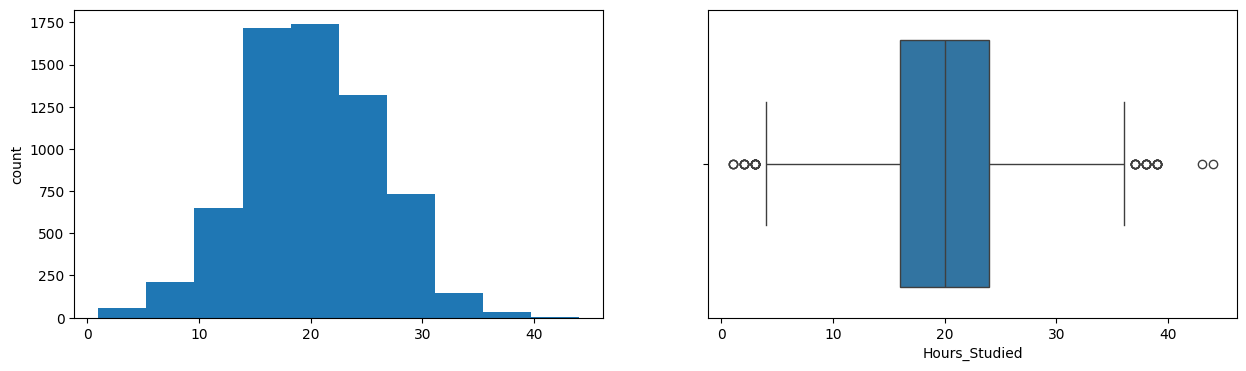

Attendance
Skew :


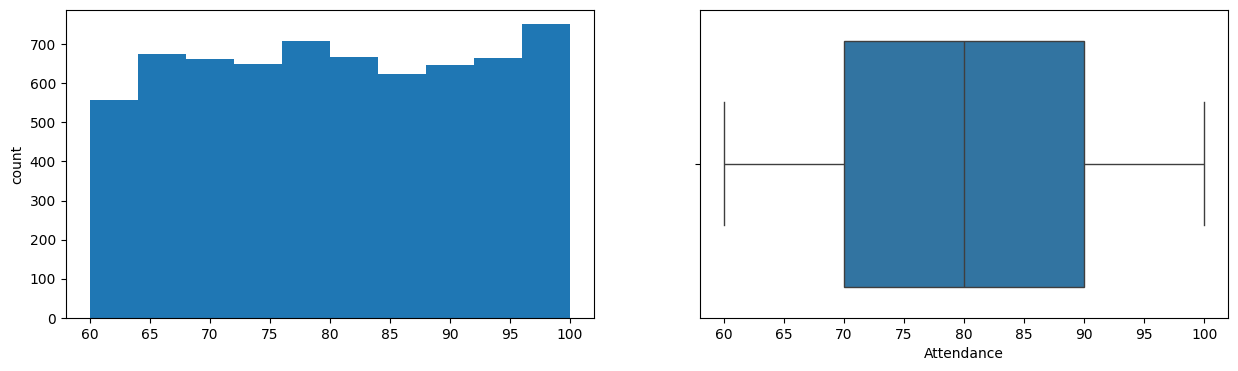

Sleep_Hours
Skew :


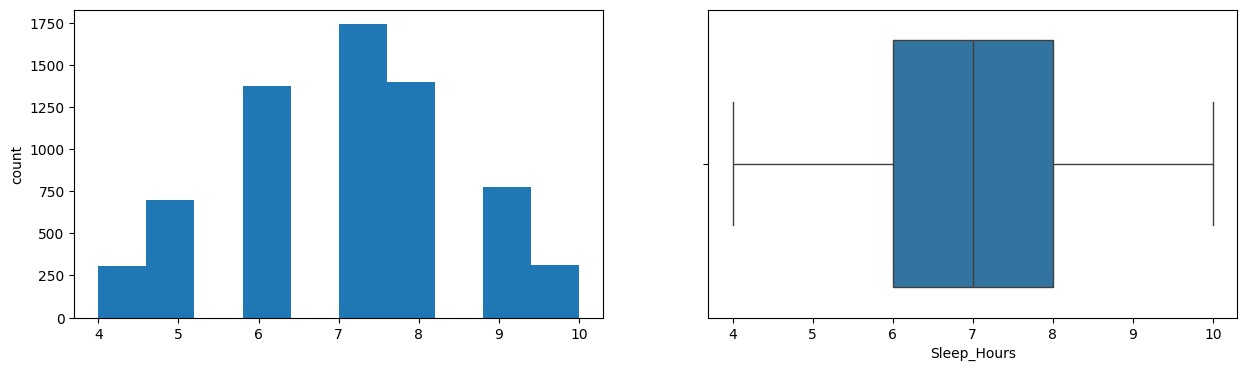

Previous_Scores
Skew :


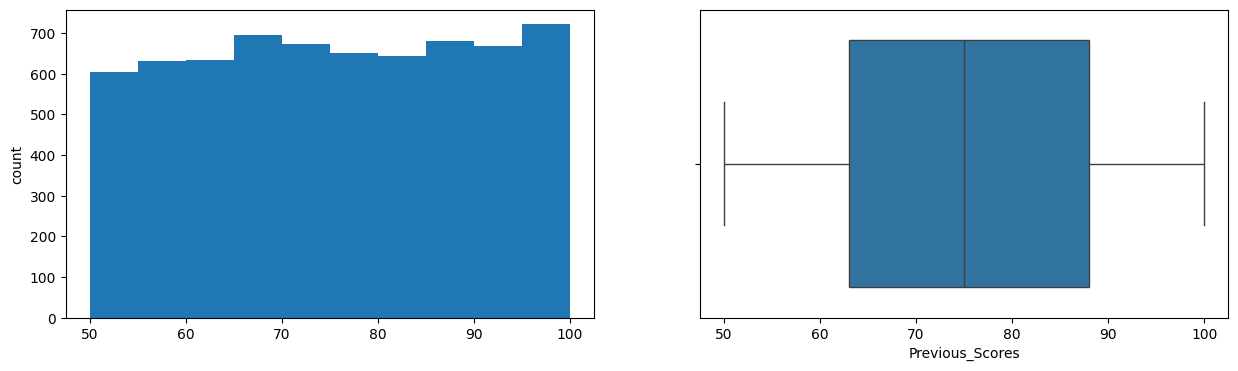

Tutoring_Sessions
Skew :


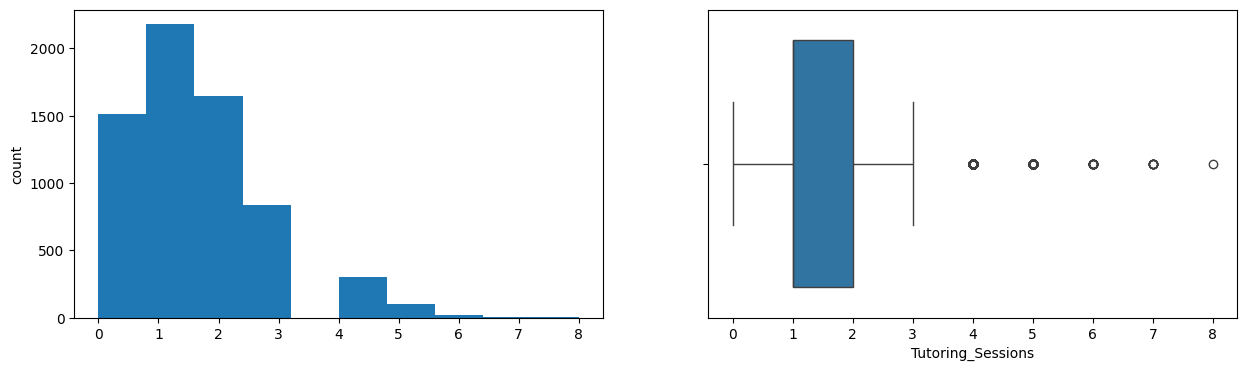

Physical_Activity
Skew :


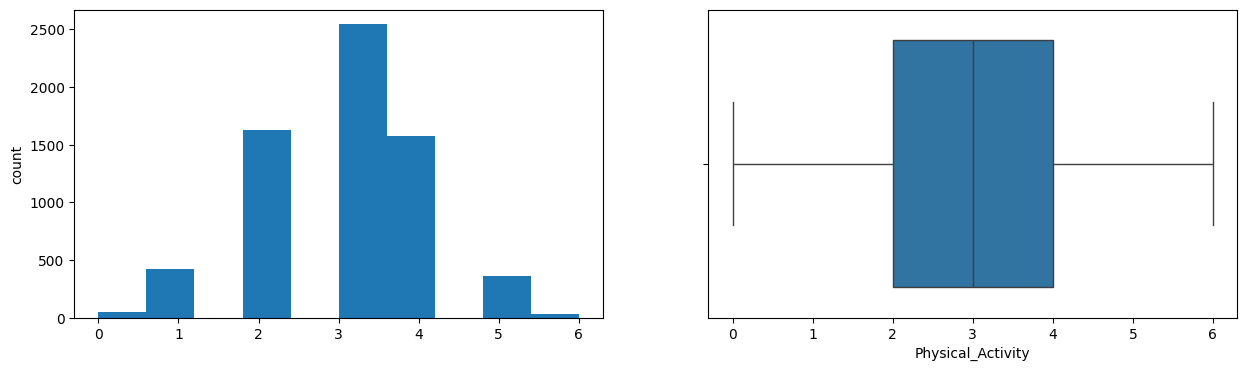

Exam_Score
Skew :


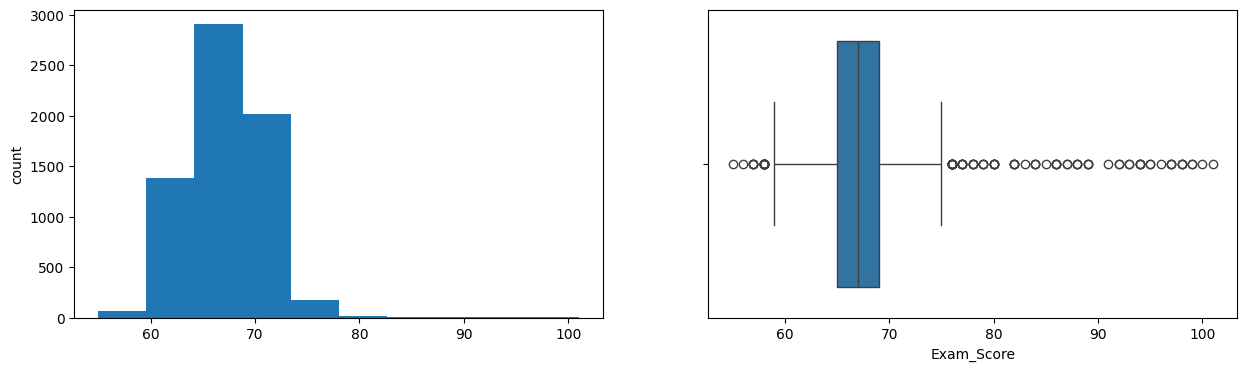

In [ ]:
#Sacaremos un pequeño perfilado de cada una de las variables numéricas calculando en nivel de asimetría que muestran:

#Estas para las variables numéricas:
for col in num_cols: # bucle "for" para cada columna que hay en la lista num_cols
    print(col) #imprime el valor de la columna numérica
    print('Skew :') #imprime el Skewness (asimetría): Si el número es 0, la distribución es simétrica;
    #si es positivo, tiene una "cola" a la derecha; si es negativo, a la izquierda
    plt.figure(figsize = (15, 4)) #crea un lienzo nuevo y alargado (15 de ancho por 4 de alto) para que los dos gráficos quepan uno al lado del otro
    plt.subplot(1, 2, 1) #divide ese lienzo en 1 fila y 2 columnas, y va a trabajar en el primer espacio (el de la izquierda) para hacer lo siguiente:
    students[col].hist(grid=False) #)dibuja el histograma de la variable actual en ese primer espacio, quitando las líneas de cuadrícula del fondo
    plt.ylabel('count') #lo que se grafica en el eje y
    plt.subplot(1, 2, 2) #se cambia al segundo espacio (el de la derecha)
    sns.boxplot(x=students[col]) #dibuja un diagrama de caja para ver rápidamente si hay valores atípicos (outliers) y dónde está la mediana
    plt.show() #muestra la figura completa con los dos gráficos y limpia la memoria para empezar la siguiente columna en la próxima vuelta del bucle
#Así este código genera estadísticas rápidas y dos gráficos comparativos por variable Numérica:
#por cada variable, hay un bloque de texto con el nombre y la asimetría, seguido de una imagen con el histograma a la izquierda (para ver la forma)
#y el boxplot a la derecha (para ver la dispersión)

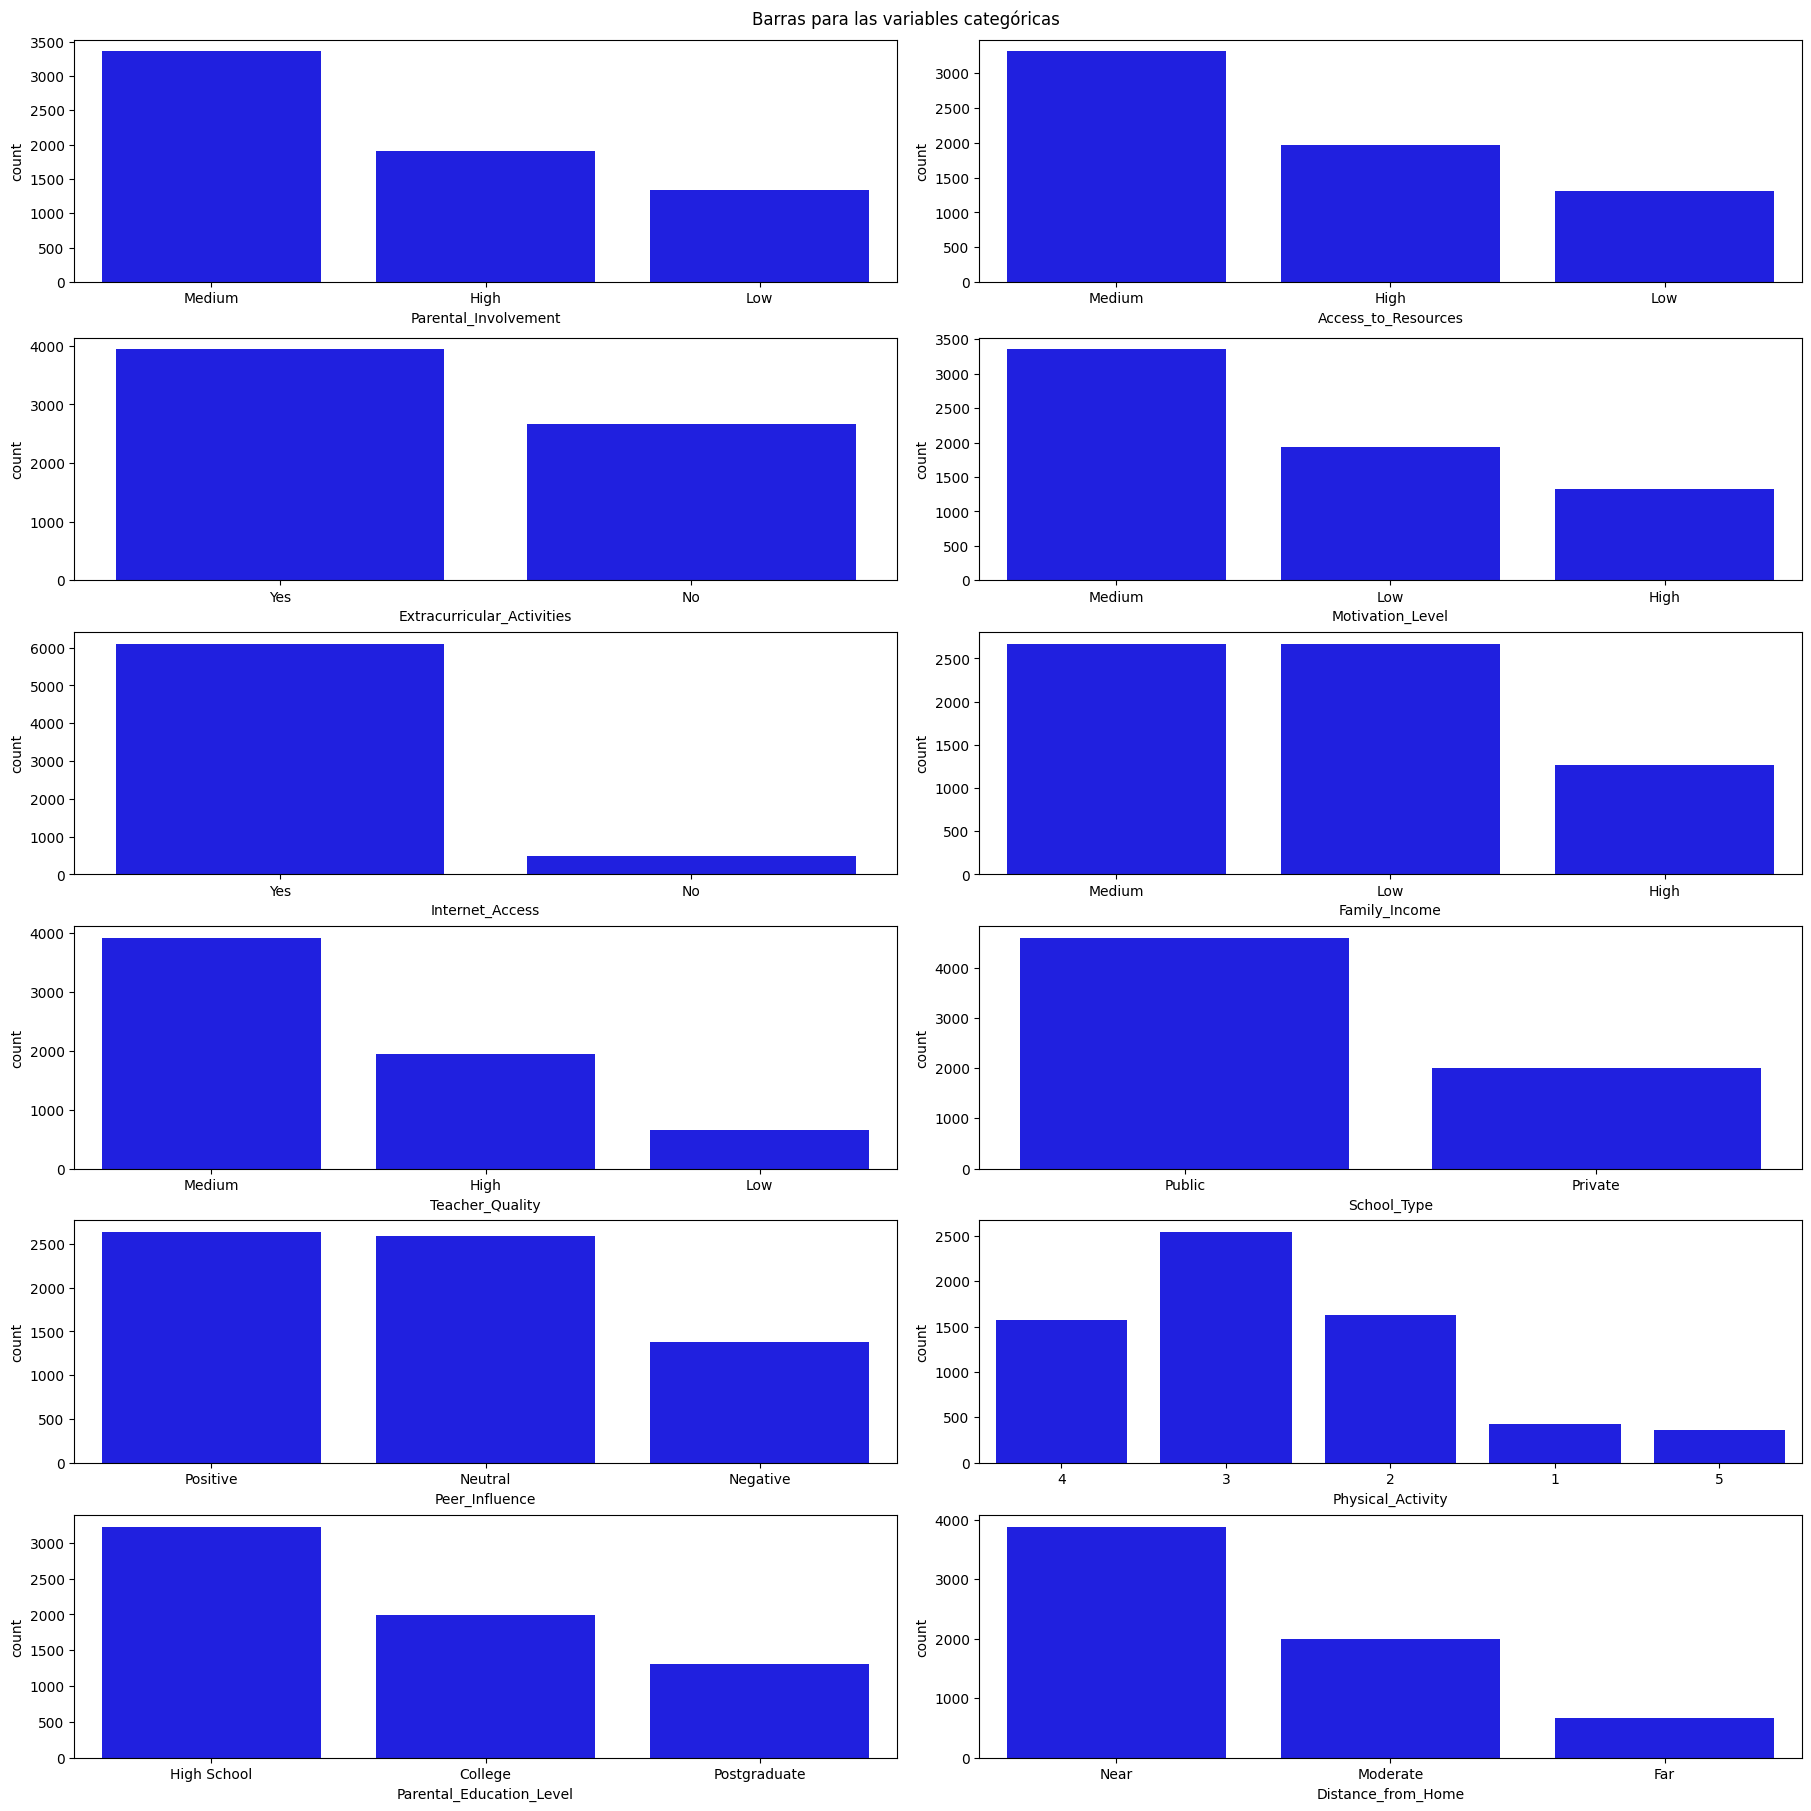

In [66]:
#Estas para las variables Categóricas:
fig, axes = plt.subplots(6, 2, figsize = (18, 18), constrained_layout = True) #se crean 6 filas y 2 columnas para graficar todas las variables Categóricas 
#hay 12 variables en total. El comando "constrained_layout = True" se ha añadido para que no se comieran los títulos de los ejes x entre fila y fila
#el comando "figsize = (18, 18)"define el tamaño total de la imagen (18 x 18 pulgadas). Es un cuadrado grande para que quepan bien los 12 subgráficos
fig.suptitle('Barras para las variables categóricas') #añade un título principal centrado en la parte superior de toda la imagen
#se dibujan gráficos de barras para todas las variables Categóricas:
sns.countplot(ax = axes[0, 0], x = 'Parental_Involvement', data = students, color = 'blue', 
              order = students['Parental_Involvement'].value_counts().index);
#Estas son las instrucciones dadas para que haga cada gráfico de barra:
#"ax = axes[0, 0]": dibuja el gráfico en las posiciones indicadas; en este caso, primera fila (0) y primera columna (0), es decir, la esquina superior izquierda
#"x = 'Parental_Involvement'": indica qué columna de datos se quiere utilizar 
#"data = students": especifica el DataFrame donde están los datos
#"color = 'blue'": pone todas las barras de color azul (si no se pone, Seaborn les asigna colores distintos automáticamente)
#"order = ... .value_counts().index": ordena las barras de mayor a menor frecuencia. Sin esto, las barras aparecerían en un orden aleatorio o alfabético
sns.countplot(ax = axes[0, 1], x = 'Access_to_Resources', data = students, color = 'blue', 
              order = students['Access_to_Resources'].value_counts().index);
sns.countplot(ax = axes[1, 0], x = 'Extracurricular_Activities', data = students, color = 'blue', 
              order = students['Extracurricular_Activities'].value_counts().index);
sns.countplot(ax = axes[1, 1], x = 'Motivation_Level', data = students, color = 'blue', 
              order = students['Motivation_Level'].head(20).value_counts().index);
sns.countplot(ax = axes[2, 0], x = 'Internet_Access', data = students, color = 'blue', 
              order = students['Internet_Access'].head(20).value_counts().index);
sns.countplot(ax = axes[2, 1], x = 'Family_Income', data = students, color = 'blue', 
              order = students['Family_Income'].head(20).value_counts().index);
sns.countplot(ax = axes[3, 0], x = 'Teacher_Quality', data = students, color = 'blue', 
              order = students['Teacher_Quality'].head(20).value_counts().index);
sns.countplot(ax = axes[3, 1], x = 'School_Type', data = students, color = 'blue', 
              order = students['School_Type'].head(20).value_counts().index);
sns.countplot(ax = axes[4, 0], x = 'Peer_Influence', data = students, color = 'blue', 
              order = students['Peer_Influence'].head(20).value_counts().index);
sns.countplot(ax = axes[4, 1], x = 'Physical_Activity', data = students, color = 'blue', 
              order = students['Physical_Activity'].head(20).value_counts().index);
sns.countplot(ax = axes[5, 0], x = 'Parental_Education_Level', data = students, color = 'blue', 
              order = students['Parental_Education_Level'].head(20).value_counts().index);
sns.countplot(ax = axes[5, 1], x = 'Distance_from_Home', data = students, color = 'blue', 
              order = students['Distance_from_Home'].head(20).value_counts().index);

In [ ]:
#Los diagramas a pares nos ayudan a entender cómo de relacionadas están las variables Numércias entre sí. Esto lo hacemos evaluando la **correlación** entre variables,
#que mide la fuerza y dirección de la relación lineal entre dos variables numéricas.
#Un valor cercano a 1 indica una relación positiva fuerte, mientras que un valor cercano a -1 indica una relación negativa fuerte. Valores próximos 
#a 0 sugieren poca o ninguna relación lineal. 
#Analizar la correlación nos ayuda a identificar qué variables pueden estar relacionadas y ser relevantes para modelos predictivos

<Figure size 1500x2000 with 0 Axes>

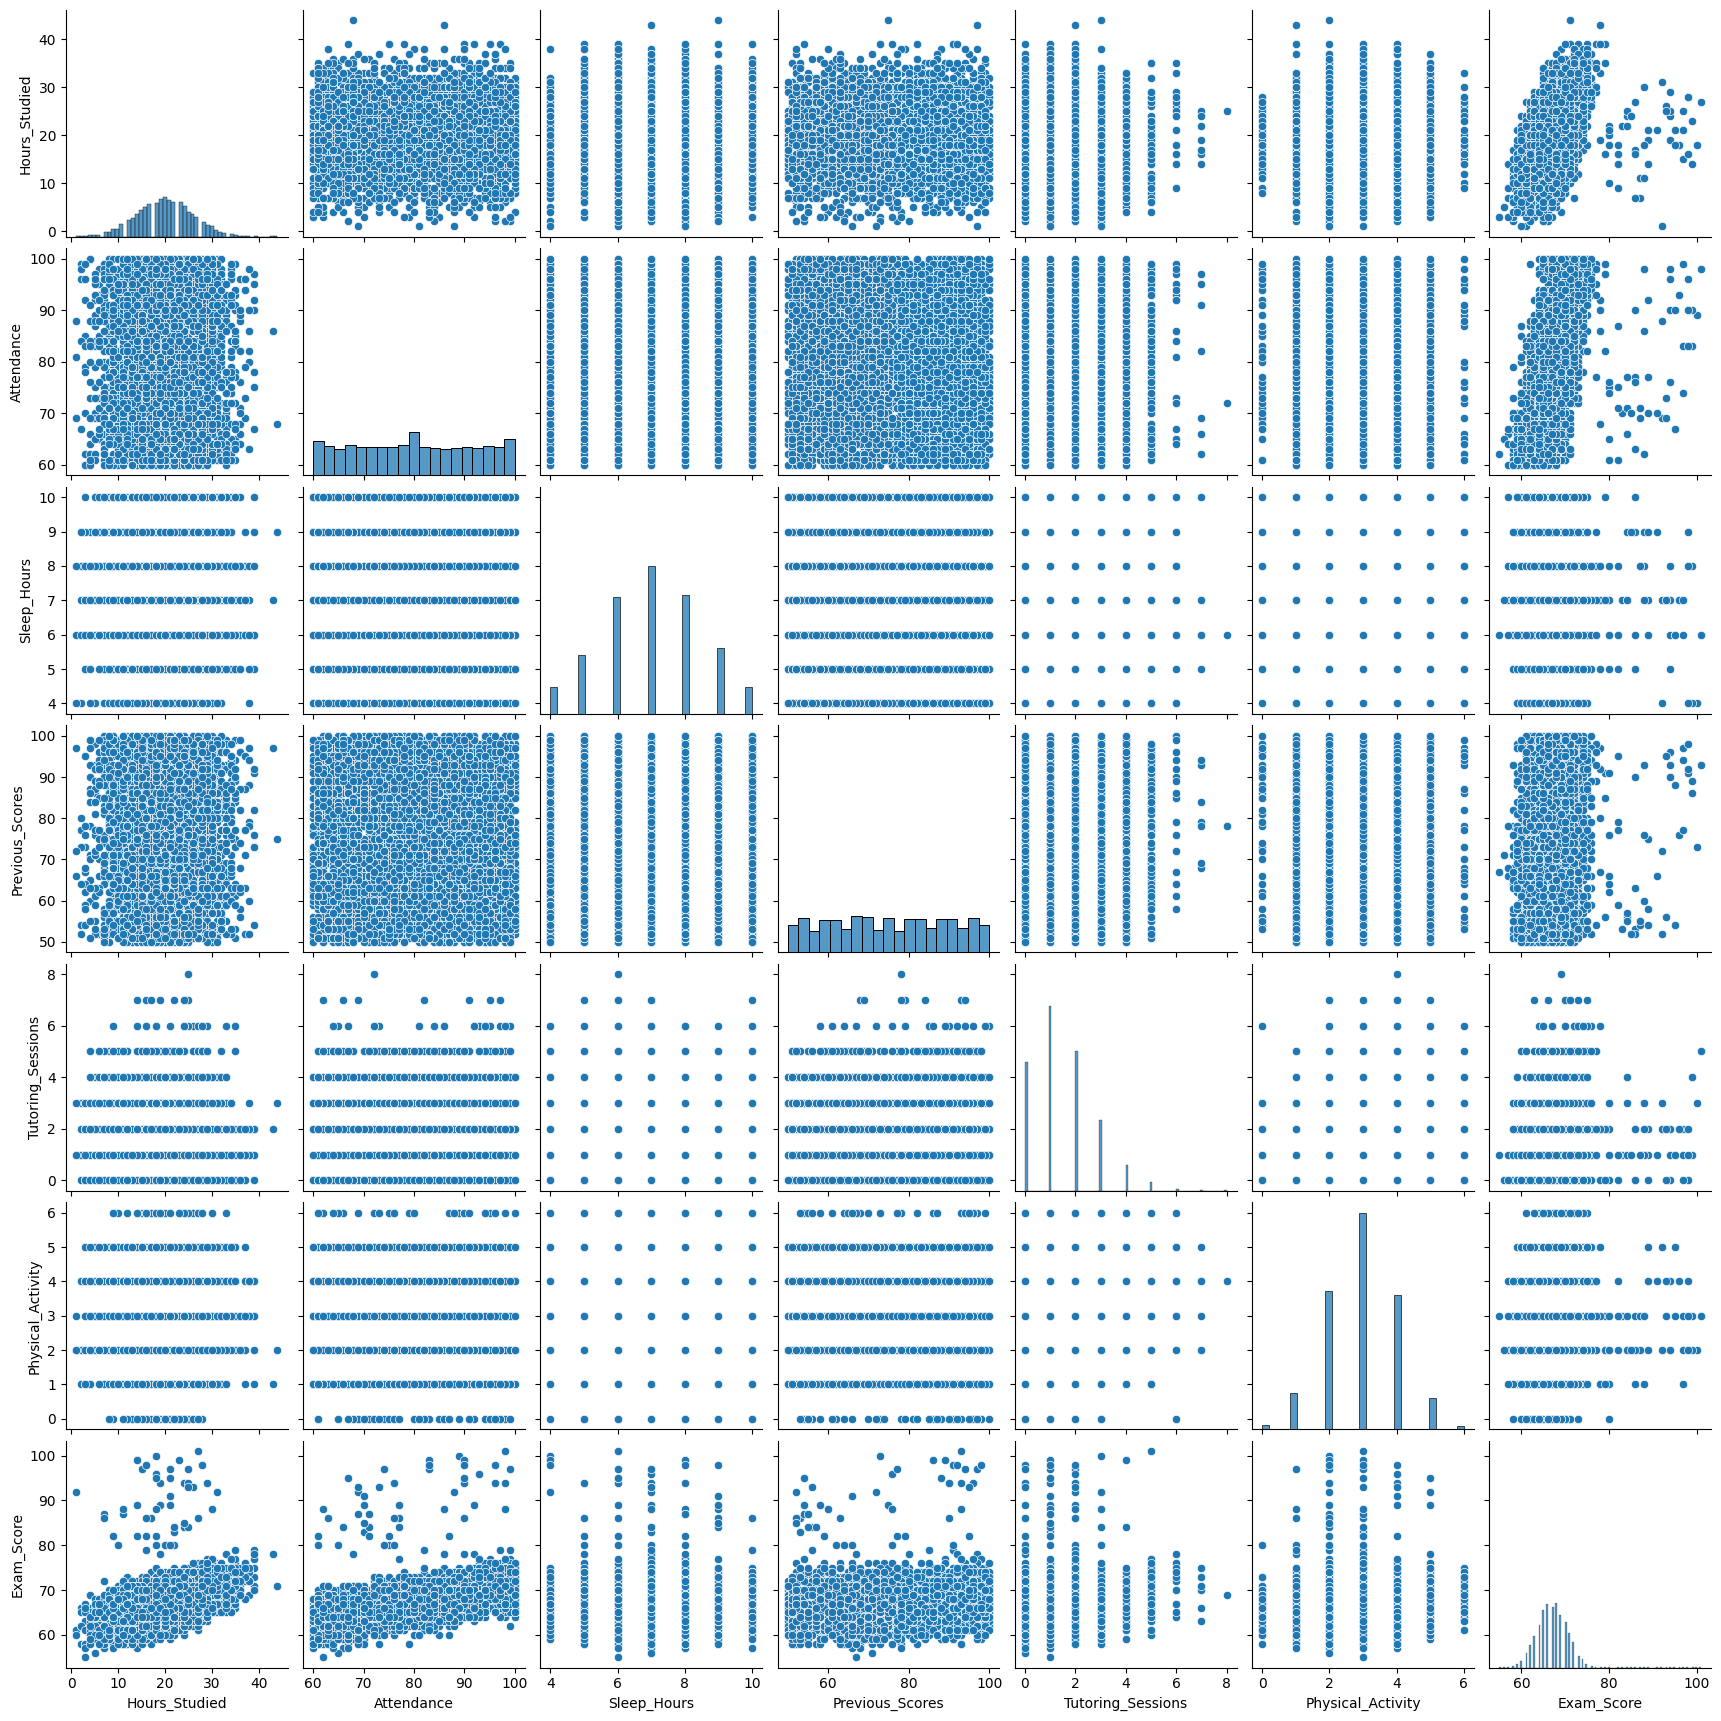

In [ ]:
#Este código genera una matriz de gráficos de dispersión (scatter plots) para comparar todas las variables numéricas del dataframe entre sí de un solo golpe.
plt.figure(figsize=(15,20)) #define el tamaño del lienzo (15 de ancho por 20 de alto)
sns.pairplot(data=students) #Crea una cuadrícula donde en las diagonales muestra la distribución de cada variable (normalmente un histograma)
#fuera de la diagonal (en los cuadros) muestra un gráfico de puntos relacionando dos variables 
#sirve para ver si hay correlaciones (si los puntos forman una línea)
plt.show() #limpia cualquier texto residual del sistema y muestra la imagen final en pantalla
#Los diagramas a pares son una forma muy rápida de detectar relaciones visuales:
#Ejemplo: si en un cuadrito los puntos suben en diagonal, significa que esas dos variables están relacionadas

In [ ]:
# hipotesis_principal = "Los estudiantes con una buena organización de estudio tienen más probabilidades de sacar mejor nota" 
# Se tienen en cuenta columnas como Attendance, Hours_Studied, Sleep_Hours y Access_to_Resources	

# subhipotesis_1 = "La importancia de la motivación de un estudiante a la hora de la nota final"
# Se tiene en cuenta la columna "Motivation_Level"

# subhipotesis_2 = "El entorno en el que ha crecido el estudiante no afecta tanto en el rendimiento de los exámenes"
# Se tienen en cuenta columnas como Family_Income, Teacher_Quality, School_Type y Parental_Education_Level

In [44]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
